# Proyecto: Web Scraping y Análisis de sentimiento de reviews de la web IMDB
![img](https://www.iebschool.com/build/static/logo-iebs.png)

<div>
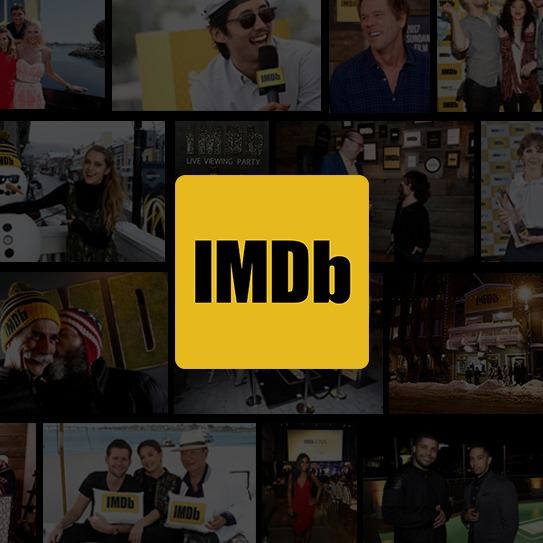
</div>



En este proyecto desarrollaremos diversas acciones de procesamiento de datos para extraer información valiosa a partir de los mismos. En concreto, accederemos a una web para extraer reviews de películas, analizar el sentimiento de dichas reviews y otorgar una puntuación a cada película.

Todo el proyecto se desarrollará en este notebook, utilizando Python como lenguaje de programación y herramienta ETL.

El proyecto está compuesto de tres fases y un apartado extra:

* **Fase 1 (2 puntos)**: En esta fase, se revisará globalmente el proyecto, de forma que quede claro el alcance del mismo. Se generará la base de datos donde se almacenarán los resultados y se implementará la función que transforme etiquetas de sentimientos (positivo, negativo, etc.) a un valor numérico.      
  <p> $\\[0.01cm]$ </p> 
    
* **Fase 2 (4 puntos)**: En esta fase, se implementarán técnicas de Web Scraping para extraer datos de reviews de la web de IMDB empleando la librería `BeautifulSoup`. Una vez onbtenidos, se automatizará el código para que sea capaz de buscar cualquier película, utilizando la librería `selenium`.    
  <p> $\\[0.01cm]$ </p> 
    
* **Fase 3 (4 puntos)**: En esta fase, se empleará una API de análisis de sentimientos, a la cual se le enviará el texto de cada review y devolverá una etiqueta con el sentimiento categorizado (`P+`, `P`, `NEU`, `N` ó `N-`). Estas etiquetas se transformarán en un valor numérico (cuya función fue implementada en la Fase 1), y se almacenará el resultado en la base de datos (también creada en la Fase 1).
  <p> $\\[0.01cm]$ </p> 

* **Extra (1 punto)**: Podrás conseguir un punto adicional si realizas el apartado extra

## Fase 1  <span style="color:red">(**2 puntos**)</span>

Para esta fase, deberás familiarizarte con el proyecto y el contenido de este notebook. Sigue las indicaciones de las siguientes celdas y contacta con el profesor en caso de dudas o errores.

En primer lugar, asegúrate de que puedes instalar e importar las siguientes librerías sin problema. No te preocupes por el contenido de las siguientes celdas, las necesitamos para configurar correctamente el entorno del notebook

In [6]:
import pandas as pd
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.by import By
from selenium import webdriver
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
import time
import requests
import sqlite3
from textblob import TextBlob

A continuación, crea una base de datos utilizando SQLite, con el nombre "BBDD_reviews.sqlite". En esta base de datos almacenaremos los resultados finales.

<span style="color:red">(**1 punto**)</span>


In [ ]:
# Creación de una base de datos SQLite

En la Fase 3, se realizará un análisis de sentimiento de las reviews de las películas. Cada review puede etiquetarse con un valor entre -1 (negativo) y 1 (positivo)

Para esta fase, se pide implementar una función llamada `avgSent` que recibirá como entrada una lista con los valores de sentimiento y devolverá el sentimiento medio. Por ejemplo, una película con 6 reviews con las siguientes etiquetas:

`[0.845, 0.712, 0.391, 0.608, 0.521, -0.214]`

tendrá el siguiente score medio:

$0.48$

NOTA: El score no debe contener más de dos dígitos decimales

<span style="color:red">(**1 punto**)</span>

In [ ]:
def avgSent(sentimientos: list[str]) -> float:
    """
    Calcula la media de los sentimientos de una lista de strings.
    
    INPUTS:
      - sentimientos: list[str] - Lista de strings que representan sentimientos.
    OUTPUTS:
      - Score (float) - Media de los sentimientos calculada como la media de las polaridades de los textos. [0,1]
    """
    # Creamos un diccionario con los valores de polaridad
    str_to_val = {
      'P+': 2,
      'P': 1,
      'NEU': 0,
      'N': -1,
      'N+': -2
    }
    score = 0
    
    for sent in sentimientos:
      score += str_to_val.get(sent, 0)
      
    # Calcular la media
    return np.mean(valores)
  # Escribe aquí tu código

Comprueba que para el ejemplo anterior obtienes el resultado esperado al llamar a la función

In [ ]:
avgSent([0.845, 0.712, 0.391, 0.608, 0.521, -0.214])

Con esto finaliza la Fase 1 del proyecto. ¡Ahora vamos a por la segunda fase!

## Fase 2  <span style="color:red">(**4 puntos**)</span>
En esta fase, utilizaremos `BeautifulSoup` para extraer las reviews de una película determinada, por ejemplo:
https://www.imdb.com/title/tt1517268/reviews/?ref_=tt_ov_rt

<p>
<div>
<img src=attachment:image.png width="500">
</div>
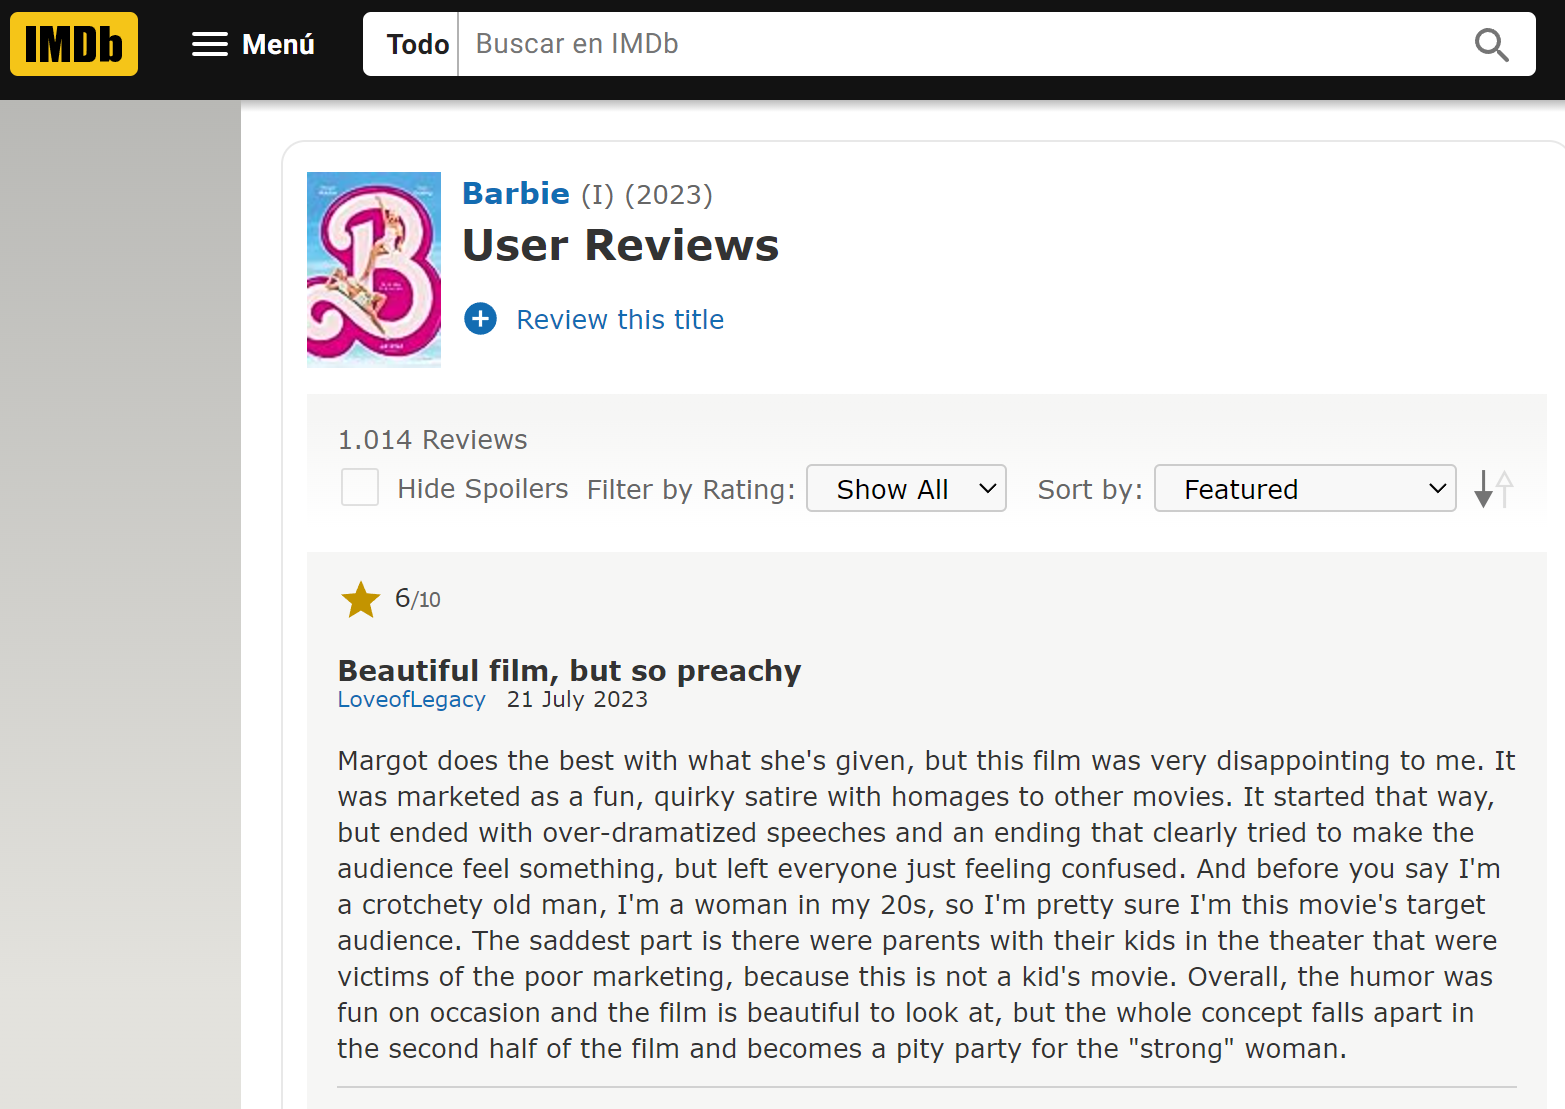

En primer lugar, extrae los textos de las reviews y almacénalos en una lista. Si no funciona a la primera, recuerda el user-agent!  
<span style="color:red">(**1 punto**)</span>

In [ ]:
# Escribe aquí tu código


Imprime por pantalla la primera y última review

In [ ]:
# Escribe aquí tu código


In [ ]:
# Escribe aquí tu código


¿Cuántas reviews has conseguido extraer?

In [ ]:
# Escribe aquí tu código


Extrae también cada una de las puntuaciones de los usuarios y almacénalos en otra lista
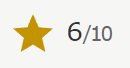

<span style="color:red">(**1 punto**)</span>

In [ ]:
# Escribe aquí tu código


Comprueba si las longitudes de las dos listas (textos y ratings) coinciden

In [ ]:
# Escribe aquí tu código


Obtén la nota media de esas reviews

In [ ]:
# Escribe aquí tu código


Observa ahora la URL de la que hemos extraído la información:
https://www.imdb.com/title/tt1517268/reviews/?ref_=tt_ov_rt

Hemos llegado hasta ella manualmente, pero, ¿y si queremos extraer las reviews de otra película? No podemos poner manualmente cada una de las URLs, por lo que vamos a utilizar la librería `selenium` para llegar a esas URLs a partir del título de las películas.

Partiendo de https://www.imdb.com, utiliza el buscador de películas y navega con selenium hasta la página de reviews de usuarios. 
  
  
NOTA: Si obtienes un error con el mensaje

*ElementClickInterceptedException: Message: element click intercepted: Element is not clickable at point...*

prueba con esta solución: 


```python
element = driver.find_element("xpath", "tu_xpath_aquí")
driver.execute_script("arguments[0].click();", element)
```

In [ ]:
# Escribe aquí tu código (puedes usar celdas de código adicionales)

Una vez hayas conseguido llegar a la URL de cualquier película, unifica todo el código en una función llamada `extract_reviews`, la cual reciba como argumento el nombre de la película y devuelva un diccionario con tres elementos:

* Una lista llamada `reviews`, que contiene los textos de las reseñas 
* Una lista llamada `scores`, que contiene las puntuaciones de los usuarios
* El valor de la nota media de las reviews en una variable llamada `avg_score`

Recuerda parar unos segundos en cada iteracción con el driver con `time.sleep()`

NOTA: Si no has conseguido avanzar con selenium, puedes dejar fija una URL de cualquier película

<span style="color:red">(**2 puntos**)</span>

In [ ]:
def extract_reviews(movie_name):
    
    # inicializo el webdriver
    
    # accedo a la web de IMDB
    
    # acepto cookies

    # busco la película

    # click en la tecla enter

    # accedo a la ficha de la película

    # accedo a las reseñas de los usuarios

    # cargo más reviews
    
    # extraigo el html de la página y lo convierto a un objeto de BeautifulSoup
    
    # cierro el driver
    
    # extraigo las reviews
    
    # extraigo los ratings

    # salida de la función

In [ ]:
# Prueba la función aquí


## Fase 3  <span style="color:red">(**4 puntos**)</span>
En esta fase, utilizaremos una librería para extraer el sentimiento de las reviews. Existen numeroros servicios web que nos ofrecen sus servicios de análisis de sentimiento. Para este proyecto, utilizaremos la librería **TextBlob**.
        


Busca la documentación de esta librería e implementa una función que devuelva el score de sentimiento entre -1 y 1. 

<span style="color:red">(**2 puntos**)</span>

In [ ]:
def sentim(text):
    # Escribe aquí tu código

Prueba la función con alguna review obtenida en el apartado anterior

In [ ]:
# Escribe aquí tu código


Ahora extrae una etiqueta de todas las reviews y guárdalas en una lista llamada `sentiments`   
<span style="color:red">(**1 punto**)</span>

In [ ]:
# Escribe aquí tu código


Sobre esa lista, aplica la función implementada en la Fase 1 para extraer un score  
<span style="color:red">(**0.25 puntos**)</span>

In [ ]:
# Escribe aquí tu código


Compara el valor obtenido con la nota media de las reviews  
<span style="color:red">(**0.25 puntos**)</span>

In [ ]:
# Escribe aquí tu código


Almacena el resultado en la base de datos generada en la Fase 1, en una tabla llamada `movies`, generando una fila con la siguiente estructura:


| Movie      | AvgScore | Sentiment |
|------------|----------|-----------|
| El Padrino | 9.6      | 0.8       |


Asegúrate de que el registro se almacena adecuadamente en la base de datos 

<span style="color:red">(**0.5 puntos**)</span>

In [ ]:
# Escribe aquí tu código


In [ ]:
# Escribe aquí tu código


## Extra <span style="color:red">(**1 punto**)</span>


Obtén el score de sentimiento de varias películas y compáralo con el rating medio de los usuarios a través de un gráfico. Calcula también el coeficiente de correlación entre ambas métricas, e interpreta el resultado